### LAB 2: MACHINE LEARNING SUPERVISED REGRESSION
 ---

#### OBJECTIVE: 
1. To understand and remember the complete Machine Learning (ML) pipeline by applying it step-by-step to a Linear Regression problem.

#### THEORY:
**Linear regression** is one of the simplest machine learning algorithms available, it is used to learn to predict continuous value (dependent variable) based on the features (independent variable) in the training dataset. The value of the dependent variable which represents the effect, is influenced by changes in the value of the independent variable.

*Simple(Single) Linear Regression*

Simple linear regression is a statistical and supervised learning method in which a single independent variable (also known as a predictor variable) is used to predict the dependent variable. In other words, it models the linear relationship between the dependent variable and a single independent variable.

Simple linear regression in machine learning is a type of linear regression. When the linear regression algorithm deals with a single independent variable, it is known as simple linear regression. When there is more than one independent variable (feature variables), it is known as multiple linear regression.

The Mathematical Equation:


y = b0 + b1 * x

y: The dependent variable.
b0: The y-intercept.
b1: The coefficient (or slope).
x: The independent variable.

*Multiple Linear Equation*

In machine learning, multiple linear regression (MLR) is a statistical technique that is used to predict the outcome of a dependent variable based on the values of multiple independent variables. The multiple linear regression algorithm is trained on data to learn a relationship (known as a regression line) that best fits the data. This relation describes how various factors affect the result. This relation is used to forecast the value of dependent variable based on the values of independent variables.

In linear regression (simple and multiple), the dependent variable is continuous (numeric value) and independent variables can be continuous or discreet (numeric value). Independent variables can also be categorical (gender, occupation), but they need to be converted to numerical values first.

The Mathematical Equation:

Here, $h\left ( x_{i} \right )$ is the predicted response value and $w_{0},w_{1},w_{2}....w_{p}$ are the regression coefficients.

Multiple Linear Regression models always includes the errors in the data known as residual error which changes the calculation as follows −

$$y_{i}=w_{0}+w_{1}x_{i1}+w_{2}x_{i2}+\cdot \cdot \cdot +w_{p}x_{ip}+e_{i}$$

We can also write the above equation as follows −

$$y_{i}=h\left ( x_{i} \right )+e_{i}\:\: or \:\: e_{i}=y_{i}-h\left ( x_{i} \right )$$

**The Machine Learning Pipeline**:

A machine learning pipeline is a systematic, automated workflow used to build, train, and deploy ml models. it includes several steps, such as:

1. Data Retrieval and Collection
2. Data Cleaning
3. Feature Design
4. Algorithm Selection
5. Loss Function Selection
6. Model Learning (Training)
7. Model Evaluation



### Example:

We will take an example dataset of Salary. and will follow and document all of the following steps of ML pipeline.


1. Data Retrieval and Collection

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics as mt

# Simulating the standard Salary Dataset for demonstration
np.random.seed(42)
years_exp = np.random.uniform(1.1, 10.5, 30)
salary = 25792 + 9449 * years_exp + np.random.normal(0, 5000, 30)

df = pd.DataFrame({'YearsExperience': years_exp, 'Salary': salary})

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (30, 2)

Columns: ['YearsExperience', 'Salary']

First 5 Rows:
   YearsExperience         Salary
0         4.620677   63697.810193
1        10.036714  122507.405216
2         7.980743   98198.847658
3         6.727390   87900.637013
4         2.566575   47035.036194


2. Data Cleaning

In [46]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Verify data types
print("\nData types:")
print(df.dtypes)

Missing values per column:
YearsExperience    0
Salary             0
dtype: int64

Data types:
YearsExperience    float64
Salary             float64
dtype: object


This dataset contains no missing values.so, no mean/median filling or row dropping is required. The data types are float64, which are appropriate for continuous numerical features.

3. Feature design

In [47]:
# Separate features and label
X = df[['YearsExperience']]
y = df['Salary']            

# Split into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 24 samples
Testing set size: 6 samples


4. Algorithm selection

For this task, we will choose Simple linear regression. Because,the relationship between work experience and salary is expected to be linear. Simple Linear Regression will be most efficient and comprehensible baseline model for mapping a single continuous input feature to a single continuous output label.

5. Loss function selection

we will choose Mean Squared Error(MSE) as our loss function. MSE measures the average squared difference between predicted and actual values, quantifying the accuracy of a model or estimator. for this task, it will measure average of the squared differences between the actual salaries ($y$) and the predicted salaries ($\hat{y}$).

6. Model training

At this stage, this model will analyze the training data to calculate the mathematical parameters that minimize the chosen loss function.

In [48]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


Learning Process: The model utilizes Ordinary Least Squares (OLS) to find the line of best fit through the training coordinates, adjusting the slope and intercept until the total MSE is minimized.

7. Model Evaluation

In [49]:
# Generate predictions
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
mse = mt.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = mt.r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {np.round(mse, 2)}")
print(f"Root Mean Squared Error (RMSE): ${np.round(rmse, 2)}")
print(f"R² Score: {np.round(r2, 2)}")

Mean Squared Error (MSE): 23493099.95
Root Mean Squared Error (RMSE): $4846.97
R² Score: 0.9


Model parameter interpretation

In [50]:
# Extract parameters
coef = model.coef_[0]
intercept = model.intercept_

print(f"Coefficient (Slope): {np.round(coef, 2)}")
print(f"Intercept: {np.round(intercept, 2)}")

Coefficient (Slope): 8655.75
Intercept: 29064.44


Model interpretation explanation:

The cofficient represents the prediction of model i.e. for every additional one year employee's salary will increase by approximately $8655.75.

Also, the intercept in this context means that the baseline salary when yearsExperience is 0, is $29064.44.


### DISCUSSION

In this lab, we successfully implemented Machine Learning(ML) pipeline to a Linear Regression problem, with a broader objective of learning about Machine Learning and Supervised regression. We used a salary dataset and employed various python libraries and tools. We split the dataset into input feature (yearsExperience as X) and target label (Salary as Y). We further chose Simple linear regression for our relationship between work experience and salary was expected to be linear. It was also chosen for being most efficient and comprehensible baseline model for mapping. We also choose Mean squared error (MSE) as our loss function to ensure that the large prediction error were squared and corrected during training.The trained model successfully converged to establish a parameteric baseline, yielding a high coefficient of determination (R² = 0.9) which demonstrated that variance within employee salaries is directly explained by career duration. The calculated slope coefficient (8655.75) proves a strong, positive relationship, indicating a reliable salary increase for each additional year of experience, while the y-intercept (29064.4) defines entry-level baseline salary.

### CONCLUSION

In this successful and informative exercise, we used ML pipeline to solve linear regression problem. We confidently converted raw salary tracking data into a reliable, verifiable forecasting formula. Ultimately, the results demonstrated that for continuous, highly correlated data, models such as this can provide very insightful data about trends and relationships. It can give us highly accurate predictions over time without risks of overfitting.

### EXTRAS

1.Visualization of regression line for Task 1.

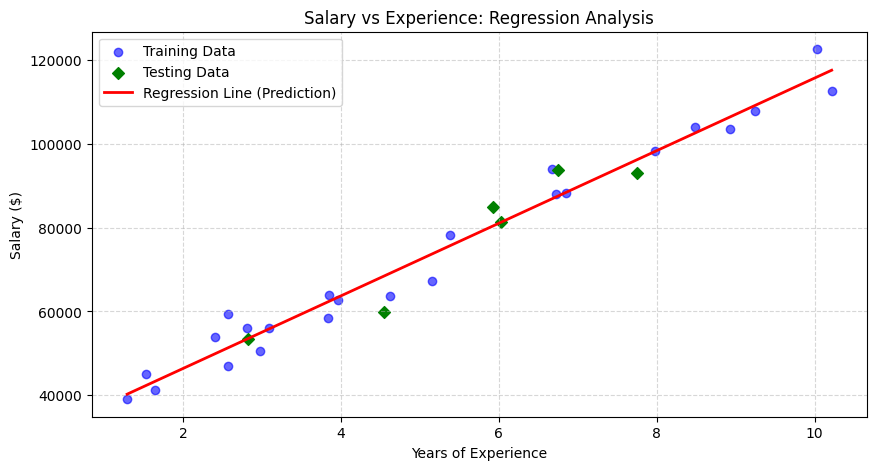

In [51]:
plt.figure(figsize=(10, 5))

# Plot actual training vs test points
plt.scatter(X_train, y_train, color="blue", label="Training Data", alpha=0.6)
plt.scatter(X_test, y_test, color="green", label="Testing Data", marker="D")

# Plot regression line
X_line_df = pd.DataFrame(X_line, columns=['YearsExperience'])
y_line = model.predict(X_line_df)
plt.plot(X_line, y_line, color="red", linewidth=2, label="Regression Line (Prediction)")

plt.xlabel("Years of Experience")
plt.ylabel("Salary ($)")
plt.title("Salary vs Experience: Regression Analysis")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

2.Plotting predicted vs actual values

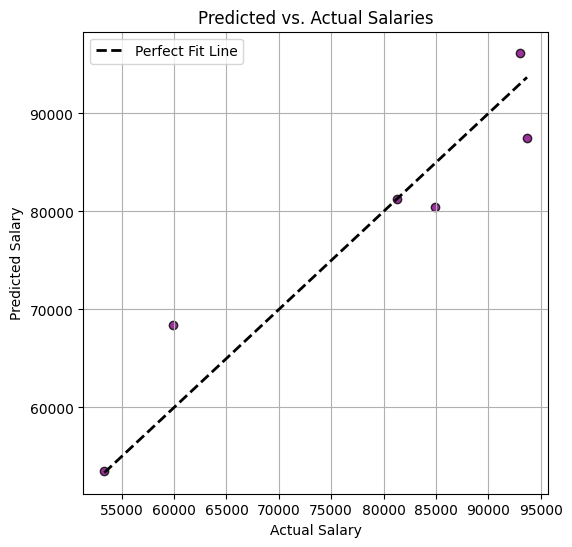

In [52]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color="purple", alpha=0.8, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect Fit Line")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted vs. Actual Salaries")
plt.legend()
plt.grid(True)
plt.show()

3.The assumptions of linear regression.

1.Linearity: The relationship between the predictor (X) and the target (Y) must be linear.

2.Independence: The residual errors must be independent of each other.

3.Normality: For any given value of X, the distribution of errors should follow a normal distribution.

4.Homoscedasticity: The variance of residual errors around the regression line should remain constant across all levels of X.